# Multimodal Spatial Domains

Conceptually, it is easy to extend SpatialLeiden to more than modality. As clustering is done on multiple graphs, the number of graphs can simply be extended. Instead of using 2 graphs (one for neighbors in physical space and one for the neighbors in the feature latent space, e.g., gene expression) we use $n+1$ graphs where $n$ is the number of modalities (see Figure below).

![image](../_static/images/multimodal.png)

To demonstrate how to cluster multiple modalities jointly we will use the simulated data from [Long _et al._ 2024](https://doi.org/10.1038/s41592-024-02316-4), which can be downloaded from [Zenodo](https://doi.org/10.5281/zenodo.10362607).

In [1]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
from mudata import MuData

from spatialleiden import spatialleiden_multimodal

# settings
simulation = Path("../path/to/data") / "Dataset13_Simulation1"

seed = 42  # random seed for reproducibility

/home/jovyan/spacehack-v3/projects/7_SpatialLeiden_multiX/SpatialLeiden2_Study/conda_envs/vignette/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## Load & prepare data

We start by loading the data and only keeping the relevant information.

In [3]:
modalities = {}

# load modalities
for file in simulation.glob("*.h5ad"):
    modality = file.stem.split("_")[1]
    adata = ad.read_h5ad(file)
    # only keep the raw counts
    adata.X = adata.layers["counts"]
    del adata.layers, adata.uns, adata.varm
    modalities[modality] = adata

From the two modalities we will construct a {py:class}`mudata.MuData` object, which is basically the multimodal extension of AnnData. We remove some duplicated information from the two modalities and construct the groundtruth labels.

In [4]:
# prepare MuData
mdata = MuData(modalities)
mdata.var_names_make_unique()

mdata.obs["groundtruth"] = pd.Categorical(
    mdata.mod["RNA"].obsm["spfac"].astype(int) @ np.array([1, 2, 3, 4])
)

mdata.obsm["spatial"] = mdata["RNA"].obsm["spatial"]

for _, mod in mdata.mod.items():
    del mod.obsm

print(mdata)

MuData object with n_obs × n_vars = 1296 × 1100
  obs:	'groundtruth'
  obsm:	'spatial'
  2 modalities
    ADT:	1296 x 100
    RNA:	1296 x 1000


/home/jovyan/spacehack-v3/projects/7_SpatialLeiden_multiX/SpatialLeiden2_Study/conda_envs/vignette/lib/python3.12/site-packages/mudata/_core/mudata.py:963: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(
/home/jovyan/spacehack-v3/projects/7_SpatialLeiden_multiX/SpatialLeiden2_Study/conda_envs/vignette/lib/python3.12/site-packages/mudata/_core/mudata.py:1629: UserWarning: Modality names will be prepended to var_names since there are identical var_names in different modalities.
  warnings.warn(


Next, we will do some basic processing steps for the two modalities. This includes library-size normalization, log-transformation, and PCA.

In [5]:
# process modalities
for name, adata in mdata.mod.items():
    n_pcs = 30 if name == "RNA" else 10

    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    sc.pp.scale(adata)
    sc.pp.pca(adata, n_comps=n_pcs, random_state=seed)

## Clustering with multimodal SpatialLeiden

To cluster the data with SpatialLeiden we will need one neighbors graph per modality. We will generate kNN graphs for each modality based on the PCA.

In [6]:
# generate kNN graph per modality
for adata in mdata.mod.values():
    sc.pp.neighbors(adata, use_rep="X_pca", random_state=seed)

As the data originates from a regular grid we can generate our spatial neighbors graph accordingly. For more information on how to generate a suitable spatial graph have a look {ref}`here <sec-spatialgraph>`.

In [7]:
# spatial neighbors
sq.gr.spatial_neighbors(mdata, coord_type="grid", n_neighs=8)

Now that we have our 3 graphs ready (the spatial graph in physical space, and the two kNN graphs in the feature latent space of the two modalities) we can proceed to cluster them using {py:func}`spatialleiden.spatialleiden_multimodal`. 
- The resolution can be uniform across all layers or set individually per layer. 
- Layer weights control each graphs influence on the clustering result (and therefore how much each modality or spatial neighborhood will contribute). 
- Additional options include specifying directed or undirected graphs and whether to use edge weights.

In [8]:
# cluster with spatialleiden
spatialleiden_multimodal(
    mdata,
    resolution=0.5,
    layer_weights={"ADT": 1, "RNA": 1.5, "spatial": 2.5},
    random_state=seed,
)

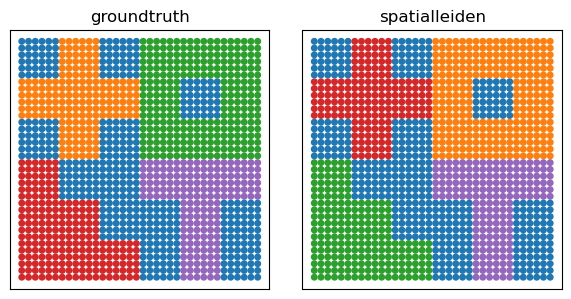

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

scatter_kwargs = dict(x="x", y="y", s=25, lw=0, legend=False)


def remove_tick_and_label(ax):
    ax.set(xticklabels=[], yticklabels=[], xlabel=None, ylabel=None)
    ax.tick_params(left=False, bottom=False)


labels = mdata.obs[["groundtruth", "spatialleiden"]]
labels[["x", "y"]] = mdata.obsm["spatial"]

fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(6, 3))

for label, ax in zip(["groundtruth", "spatialleiden"], axs):
    _ = sns.scatterplot(data=labels, hue=label, ax=ax, **scatter_kwargs)
    ax.set(title=label, aspect=1)
    remove_tick_and_label(ax)

fig.tight_layout()